In [1]:
!pip install -Uqq fastbook

In [2]:
from fastbook import *
from fastai.vision.widgets import *

In [3]:
# While it may look unintuitive, it is recommended to first train the model and then clean the data to make it easier to figure out why the data is wrong

In [4]:
!pip install -U ddgs

Defaulting to user installation because normal site-packages is not writeable


In [17]:
from ddgs import DDGS

def search_images_ddg(term, max_results=100):
    with DDGS() as ddgs:
        results = list(ddgs.images(term, max_results=max_results))
    return [r["image"] for r in results]

ims = search_images_ddg("grizzly bear")
len(ims)

35

In [18]:
dest = 'images/grizzly.jpg'
download_url(ims[0], dest)

<div><progress max="129988" value="131072"></progress> 100.83% [131072/129988 00:00&lt;00:00]</div>

Path('images/grizzly.jpg')

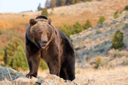

In [19]:
im = Image.open(dest)
im.to_thumb(128,128)

In [20]:
# use fastai's download_images to download all the URLs
bear_types = 'grizzly','black','teddy'
path = Path('bears')

In [25]:
if not path.exists():
    path.mkdir()
    for o in bear_types:
        dest = (path/o)
        dest.mkdir(exist_ok=True)
        # 1. Fetch URLs (returns a list of string URLs)
        results = search_images_ddg(f'{o} bear')
        # 2. Pass results directly to urls parameter
        download_images(dest, urls=results)

In [27]:
# Our folder has image files
fns = get_image_files(path)
len(fns)

96

In [28]:
# Corrup images
failed = verify_images(fns)
failed

[Path('bears/grizzly/e80173a6-7bcd-41a8-ab9b-9ad11c27a966.jpg')]

In [29]:
# To remove all the failed images, you can use unlink on each of them. 
#Note that, like most fastai functions that return a collection, verify_images 
#returns an object of type L, which includes the map method. 
#This calls the passed function on each element of the collection:
failed.map(Path.unlink);

In [13]:
# Jupyter notebook tips:
# At any point, if you don't remember the exact spelling of a function or argument name, you can press Tab to get autocompletion suggestions.
# When inside the parentheses of a function, pressing Shift and Tab simultaneously will display a window with the signature of the function and a short description. Pressing these keys twice will expand the documentation, and pressing them three times will open a full window with the same information at the bottom of your screen.
# In a cell, typing ?func_name and executing will open a window with the signature of the function and a short description.
# In a cell, typing ??func_name and executing will open a window with the signature of the function, a short description, and the source code.
# If you are using the fastai library, we added a doc function for you: executing doc(func_name) in a cell will open a window with the signature of the function, a short description and links to the source code on GitHub and the full documentation of the function in the library docs.
# Unrelated to the documentation but still very useful: to get help at any point if you get an error, type %debug in the next cell and execute to open the Python debugger, which will let you inspect the content of every variable.

In [14]:
# DataLoaders: A fastai class that stores multiple DataLoader objects you pass to it, normally a train and a valid, although it's possible to have as many as you like. The first two are made available as properties.
# class DataLoaders(GetAttr):
#     def __init__(self, *loaders): self.loaders = loaders
#     def __getitem__(self, i): return self.loaders[i]
#     train,valid = add_props(lambda i,self: self[i])

In [30]:
bears = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=Resize(128))
# This command has given us a DataBlock object. This is like a template for creating a DataLoaders

In [31]:
dls = bears.dataloaders(path)
# A DataLoaders includes validation and training DataLoaders. DataLoader is a 
# class that provides batches of a few items at a time to the GPU. We'll be 
# learning a lot more about this class in the next chapter. When you loop through 
# a DataLoader fastai will give you 64 (by default) items at a time, all stacked up 
# into a single tensor. 

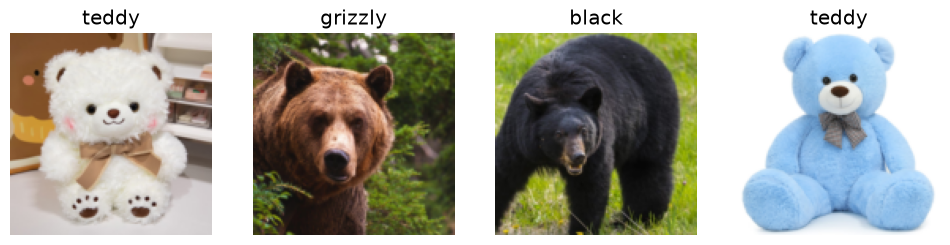

In [32]:
# We can take a look at a few of those items by calling the show_batch method on a DataLoader:
dls.valid.show_batch(max_n=4, nrows=1)

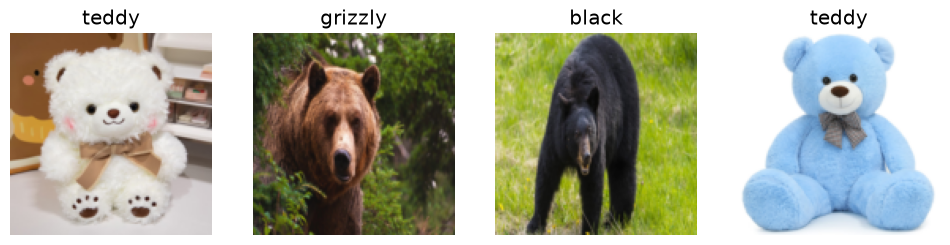

In [33]:
# By default Resize crops the images to fit a square shape of the size requested, 
# using the full width or height. This can result in losing some important details. 
# Alternatively, you can ask fastai to pad the images with zeros (black), or 
# squish/stretch them:
bears = bears.new(item_tfms=Resize(128, ResizeMethod.Squish))
dls = bears.dataloaders(path)
dls.valid.show_batch(max_n=4, nrows=1)

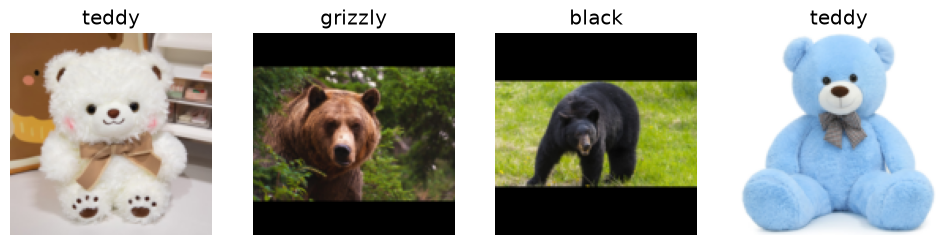

In [34]:
bears = bears.new(item_tfms=Resize(128, ResizeMethod.Pad, pad_mode='zeros'))
dls = bears.dataloaders(path)
dls.valid.show_batch(max_n=4, nrows=1)

In [ ]:
# All of these approaches seem somewhat wasteful, or problematic. If we squish or stretch the images they end up as unrealistic shapes, leading to a model that learns that things look different to how they actually are, which we would expect to result in lower accuracy. If we crop the images then we remove some of the features that allow us to perform recognition. For instance, if we were trying to recognize breeds of dog or cat, we might end up cropping out a key part of the body or the face necessary to distinguish between similar breeds. If we pad the images then we have a whole lot of empty space, which is just wasted computation for our model and results in a lower effective resolution for the part of the image we actually use.

# Instead, what we normally do in practice is to randomly select part of the image, and crop to just that part. On each epoch (which is one complete pass through all of our images in the dataset) we randomly select a different part of each image. This means that our model can learn to focus on, and recognize, different features in our images. It also reflects how images work in the real world: different photos of the same thing may be framed in slightly different ways.

# In fact, an entirely untrained neural network knows nothing whatsoever about how images behave. It doesn't even recognize that when an object is rotated by one degree, it still is a picture of the same thing! So actually training the neural network with examples of images where the objects are in slightly different places and slightly different sizes helps it to understand the basic concept of what an object is, and how it can be represented in an image.

# Here's another example where we replace Resize with RandomResizedCrop, which is the transform that provides the behavior we just described. The most important parameter to pass in is min_scale, which determines how much of the image to select at minimum each time:

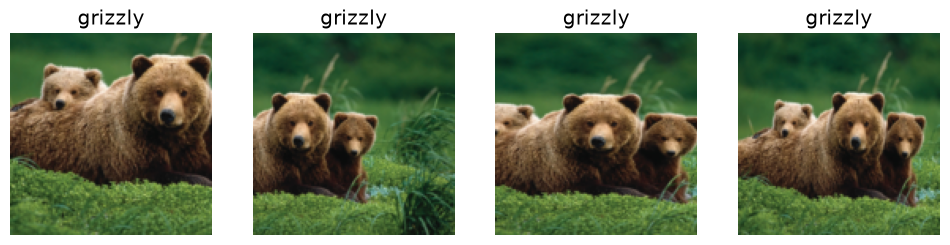

In [35]:
bears = bears.new(item_tfms=RandomResizedCrop(128, min_scale=0.3))
dls = bears.dataloaders(path)
dls.train.show_batch(max_n=4, nrows=1, unique=True)
# We used unique=True to have the same image repeated with different versions of this 
# RandomResizedCrop transform. This is a specific example of a more general technique, 
# called data augmentation.

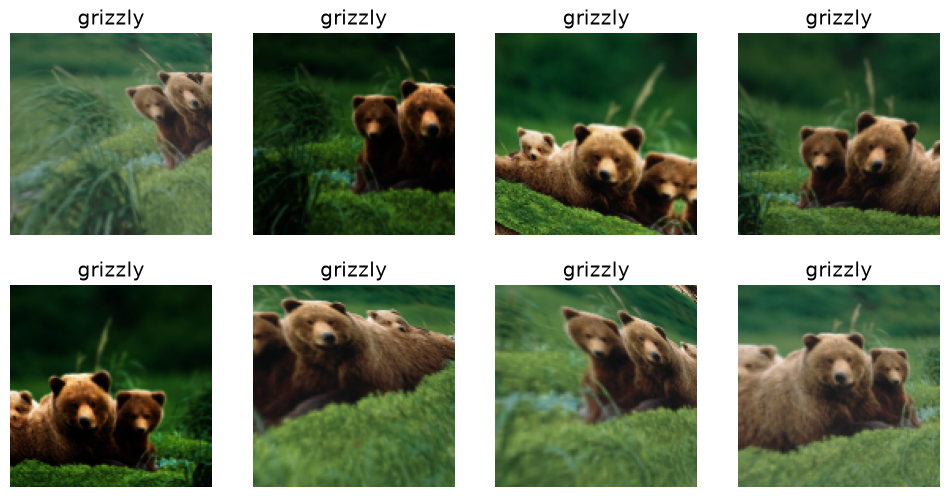

In [36]:
# Data augmentation refers to creating random variations of our input data, such that they appear different, but do not actually change the meaning of the data. Examples of common data augmentation techniques for images are rotation, flipping, perspective warping, brightness changes and contrast changes. For natural photo images such as the ones we are using here, a standard set of augmentations that we have found work pretty well are provided with the aug_transforms function. Because our images are now all the same size, we can apply these augmentations to an entire batch of them using the GPU, which will save a lot of time. To tell fastai we want to use these transforms on a batch, we use the batch_tfms parameter 
bears = bears.new(item_tfms=Resize(128), batch_tfms=aug_transforms(mult=2))
dls = bears.dataloaders(path)
dls.train.show_batch(max_n=8, unique=True)

In [37]:
# We don't have a lot of data for our problem (150 pictures of each sort of bear at most), so to train our model, we'll use RandomResizedCrop with an image size of 224 px, which is fairly standard for image classification, and default aug_transforms:
bears = bears.new(
    item_tfms=RandomResizedCrop(224, min_scale=0.5),
    batch_tfms=aug_transforms())
dls = bears.dataloaders(path)

In [38]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(4)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/vaishnavi-asawale/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████████████████████████████████| 44.7M/44.7M [00:07<00:00, 6.40MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,2.116956,2.618945,0.684211,00:20


epoch,train_loss,valid_loss,error_rate,time
0,1.630141,1.308230,0.578947,00:22
1,1.503116,0.231599,0.105263,00:23
2,1.163745,0.153603,0.052632,00:23
3,0.928264,0.133208,0.052632,00:21


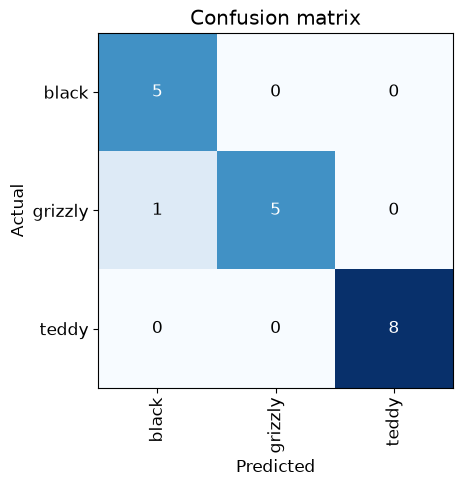

In [39]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

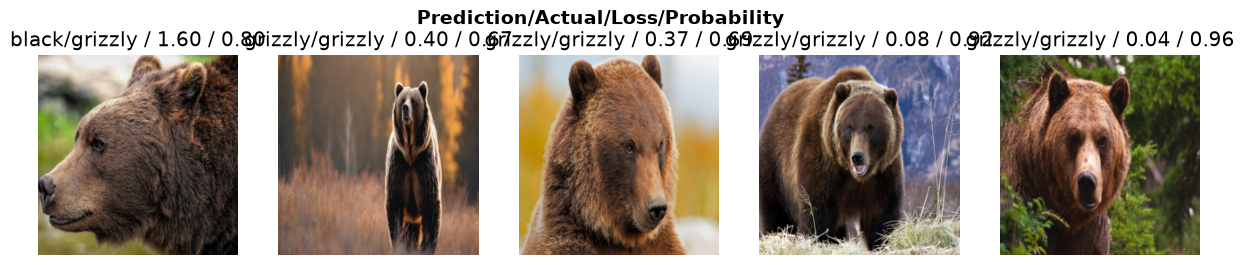

In [40]:
# The loss is a number that is higher if the model is incorrect (especially if it's 
# also confident of its incorrect answer), or if it's correct, but not confident of 
# its correct answer. Each image is labeled with four things: prediction, actual 
# (target label), loss, and probability. The probability here is the confidence level,
# from zero to one, that the model has assigned to its prediction:

interp.plot_top_losses(5, nrows=1)

In [41]:
# fastai includes a handy GUI for data cleaning called ImageClassifierCleaner that 
# allows you to choose a category and the training versus validation set and view the 
# highest-loss images (in order), along with menus to allow images to be selected for 
# removal or relabeling:
cleaner = ImageClassifierCleaner(learn)
cleaner

In [ ]:
# for idx in cleaner.delete(): cleaner.fns[idx].unlink()
# for idx,cat in cleaner.change(): shutil.move(str(cleaner.fns[idx]), path/cat)

In [42]:
learn.export()
# When you call export, fastai will save a file called "export.pkl"

In [43]:
# Let's check that the file exists, by using the ls method that fastai adds to 
# Python's Path class:
path = Path()
path.ls(file_exts='.pkl')

[Path('export.pkl')]